# Project 10: Transformer 번역기 (Korean → English)

## 0. 환경 설정
- GPU: `cuda:1` (TITAN RTX)
- 데이터: [Korean-English News Corpus](https://github.com/jungyeul/korean-parallel-corpora)
- 모델: Transformer (Seq2Seq with weight tying)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sentencepiece as spm
import matplotlib.pyplot as plt
import seaborn

import re, os, math, random
from tqdm.notebook import tqdm

print(f"torch: {torch.__version__}")

device = torch.device("cuda:1" if torch.cuda.device_count() > 1 else
                      "cuda"   if torch.cuda.is_available()        else
                      "cpu")
print(f"device: {device}")

torch: 2.11.0+cu128
device: cuda:1


## 1. 데이터 다운로드

In [2]:
os.makedirs("./data", exist_ok=True)

ko_path  = "./data/korean-english-park.train.ko"
eng_path = "./data/korean-english-park.train.en"

if not os.path.exists(ko_path):
    import urllib.request, gzip, tarfile
    url = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    urllib.request.urlretrieve(url, "./data/korean-english-park.train.tar.gz")
    with tarfile.open("./data/korean-english-park.train.tar.gz", "r:gz") as t:
        t.extractall("./data")

print("ko  lines:", sum(1 for _ in open(ko_path,  encoding="utf-8")))
print("eng lines:", sum(1 for _ in open(eng_path, encoding="utf-8")))

ko  lines: 94123
eng lines: 94123


## 2. 전처리

In [3]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[ ]+', " ", sentence)
    return sentence.strip()

def clean_corpus(ko_path, eng_path):
    with open(ko_path,  "r", encoding="utf-8") as f: ko  = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f: eng = f.read().splitlines()
    assert len(ko) == len(eng)
    pairs = list(set(["\t".join([k, e]) for k, e in zip(ko, eng)]))
    return pairs

cleaned_corpus = clean_corpus(ko_path, eng_path)
print(f"총 쌍 수: {len(cleaned_corpus)}")
print("예시:", cleaned_corpus[0][:80])

총 쌍 수: 78968
예시: 항공사는 쉬라 조쉬의 나이에 그 정도 신장이라면 65kg이어야 한다고 말했다.	The airline says that someone who is


## 3. 토크나이저 (SentencePiece)

In [4]:
SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

def generate_tokenizer(corpus, vocab_size, lang, pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    file  = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    with open(file, "w", encoding="utf-8") as f:
        for row in corpus: f.write(row + "\n")
    spm.SentencePieceTrainer.Train(
        f"--input={file} --model_prefix={model} --vocab_size={vocab_size}"
        f" --pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f"{model}.model")
    return tokenizer

kor_corpus, eng_corpus = [], []
for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

print("ko vocab:", ko_tokenizer.get_piece_size())
print("en vocab:", en_tokenizer.get_piece_size())

ko vocab: 20000
en vocab: 20000


## 4. 시퀀스 패딩 & DataLoader

In [5]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

MAX_LEN    = 50
BATCH_SIZE = 64

src_corpus, tgt_corpus = [], []
for idx in tqdm(range(len(kor_corpus)), desc="필터링"):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])
    if len(src_tokens) <= MAX_LEN and len(tgt_tokens) <= MAX_LEN:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

print(f"필터링 후 쌍 수: {len(src_corpus)}")

enc_all = torch.nn.utils.rnn.pad_sequence(src_corpus, batch_first=True, padding_value=0)
dec_all = torch.nn.utils.rnn.pad_sequence(tgt_corpus, batch_first=True, padding_value=0)

# 5% 검증셋 분리
enc_tr, enc_val, dec_tr, dec_val = train_test_split(
    enc_all, dec_all, test_size=0.05, random_state=42
)
print(f"train: {len(enc_tr)}, val: {len(enc_val)}")
print(enc_tr.shape, dec_tr.shape)

train_dataset    = TensorDataset(enc_tr, dec_tr)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

val_dataset    = TensorDataset(enc_val, dec_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"train 배치 수: {len(train_dataloader)}, val 배치 수: {len(val_dataloader)}")


필터링:   0%|          | 0/78968 [00:00<?, ?it/s]

필터링 후 쌍 수: 72107
train: 68501, val: 3606
torch.Size([68501, 50]) torch.Size([68501, 50])
train 배치 수: 1071, val 배치 수: 57


## 5. 모델 구성 요소

In [6]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    table = np.array([[cal_angle(p, i) for i in range(d_model)] for p in range(pos)])
    table[:, 0::2] = np.sin(table[:, 0::2])
    table[:, 1::2] = np.cos(table[:, 1::2])
    return table

print("슝=3")

슝=3


In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model   = d_model
        self.depth     = d_model // num_heads
        assert d_model % num_heads == 0

        self.W_q    = nn.Linear(d_model, d_model)
        self.W_k    = nn.Linear(d_model, d_model)
        self.W_v    = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scaled_qk = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        if mask is not None:
            scaled_qk += (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        return torch.matmul(attentions, V), attentions

    def split_heads(self, x):
        bsz, seq, _ = x.shape
        return x.view(bsz, seq, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, _, seq, _ = x.shape
        return x.permute(0, 2, 1, 3).contiguous().view(bsz, seq, self.d_model)

    def forward(self, Q, K, V, mask=None):
        out, attn = self.scaled_dot_product_attention(
            self.split_heads(self.W_q(Q)),
            self.split_heads(self.W_k(K)),
            self.split_heads(self.W_v(V)),
            mask
        )
        return self.linear(self.combine_heads(out)), attn

print("슝=3")

슝=3


In [8]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1  = nn.Linear(d_model, d_ff)
        self.fc2  = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

print("슝=3")

슝=3


In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn    = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out) + residual

        residual = out
        out = self.dropout(self.ffn(self.norm_2(out))) + residual
        return out, enc_attn

print("슝=3")

슝=3


In [10]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn  = MultiHeadAttention(d_model, num_heads)
        self.ffn    = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out) + residual

        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out) + residual

        residual = out
        out = self.dropout(self.ffn(self.norm_3(out))) + residual
        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


In [11]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        enc_attns = []
        for layer in self.enc_layers:
            x, attn = layer(x, mask)
            enc_attns.append(attn)
        return self.final_norm(x), enc_attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        dec_attns, dec_enc_attns = [], []
        for layer in self.dec_layers:
            x, da, dea = layer(x, enc_out, causality_mask, padding_mask)
            dec_attns.append(da); dec_enc_attns.append(dea)
        return self.final_norm(x), dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [12]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.3, shared=True):
        super().__init__()
        self.d_model = float(d_model)
        self.shared  = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        pos_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_np, dtype=torch.float32))

        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc      = nn.Linear(d_model, tgt_vocab_size)

        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        out = emb(x)
        if self.shared:
            out = out * math.sqrt(self.d_model)
        return self.dropout(out + self.pos_encoding[:x.size(1), :].unsqueeze(0).to(x.device))

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_out, enc_attns = self.encoder(self.embedding(self.enc_emb, enc_in), enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            self.embedding(self.dec_emb, dec_in), enc_out, causality_mask, dec_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 6. 마스킹 함수

In [13]:
def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(src_len, tgt_len):
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    enc_mask     = generate_padding_mask(src)
    dec_enc_mask = enc_mask  # cross-attention: src padding mask만 사용

    dec_pad_mask      = generate_padding_mask(tgt)
    dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    dec_mask = torch.max(dec_pad_mask, dec_causality_mask.to(dec_pad_mask.device))

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")


슝=3


## 7. 모델 & 옵티마이저 초기화

In [14]:
class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch + 1)
        lr   = (self.d_model ** -0.5) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return [lr for _ in self.base_lrs]

d_model = 512
transformer = Transformer(
    n_layers=2, d_model=d_model, n_heads=8, d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200, dropout=0.3, shared=True
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(), lr=1e-9, betas=(0.9, 0.98), eps=1e-9)
lr_scheduler = LearningRateScheduler(optimizer, d_model=d_model)

print(f"파라미터 수: {sum(p.numel() for p in transformer.parameters()):,}")
print("슝=3")

파라미터 수: 35,214,880
슝=3


## 8. 손실 함수 & 학습 스텝

In [15]:
loss_object = nn.CrossEntropyLoss(reduction="none")

def loss_function(real, pred):
    mask  = (real != 0)
    loss_ = loss_object(pred, real)
    mask  = mask.float()
    loss_ *= mask
    return loss_.sum() / mask.sum()


def train_step(src, tgt, model, optimizer):
    src = src.to(device)
    tgt = tgt.to(device)
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
    enc_mask    = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask    = dec_mask.to(device)

    optimizer.zero_grad()
    preds, enc_attns, dec_attns, dec_enc_attns = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)

    # predictions[:, :-1] vs gold (shift 맞춤)
    loss = loss_function(gold.contiguous().view(-1),
                         preds[:, :-1].contiguous().view(-1, preds.size(-1)))
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 9. 학습 루프

In [16]:
NO_REPEAT_NGRAM_SIZE = 3

def creates_repeated_ngram(generated_ids, token_id, n):
    if n <= 0 or len(generated_ids) < n - 1:
        return False
    ngram = generated_ids[-(n - 1):] + [token_id]
    for i in range(len(generated_ids) - n + 1):
        if generated_ids[i:i + n] == ngram:
            return True
    return False

def select_next_token(logits, generated_ids, no_repeat_ngram_size=3, pad_id=0):
    sorted_ids = torch.argsort(logits, descending=True).tolist()
    for token_id in sorted_ids:
        if token_id == pad_id:
            continue
        if not creates_repeated_ngram(generated_ids, token_id, no_repeat_ngram_size):
            return token_id
    return sorted_ids[0]

print("슝=3")


슝=3


In [17]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def compute_val_bleu(model, dataloader, tgt_tokenizer):
    model.eval()
    hypotheses, references = [], []
    smoothie = SmoothingFunction().method1

    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(device)
            for i in range(src.size(0)):
                s = src[i].unsqueeze(0)
                output = torch.tensor([tgt_tokenizer.bos_id()], device=device).unsqueeze(0)
                ids = []
                for _ in range(dec_tr.shape[-1]):
                    enc_mask, dec_enc_mask, dec_mask = generate_masks(s, output)
                    logits, *_ = model(
                        s, output,
                        enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device)
                    )
                    pred_id = select_next_token(logits[0, -1], ids, NO_REPEAT_NGRAM_SIZE)
                    if pred_id == tgt_tokenizer.eos_id():
                        break
                    ids.append(pred_id)
                    output = torch.cat([output, torch.tensor([[pred_id]], device=device)], dim=-1)

                hyp = tgt_tokenizer.decode_ids(ids).split()
                ref_ids = tgt[i].tolist()
                # PAD(0), BOS(1), EOS(2) 제거
                ref_ids = [t for t in ref_ids if t not in (0, 1, 2)]
                ref = tgt_tokenizer.decode_ids(ref_ids).split()
                hypotheses.append(hyp)
                references.append([ref])

    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    model.train()
    return score

print("슝=3")


슝=3


In [18]:
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    sentence = preprocess_sentence(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    _input = torch.tensor(tokens, device=device).unsqueeze(0)

    ids = []
    output = torch.tensor([tgt_tokenizer.bos_id()], device=device).unsqueeze(0)
    pieces = src_tokenizer.encode_as_pieces(sentence)

    model.eval()
    with torch.no_grad():
        for _ in range(dec_tr.shape[-1]):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)
            predictions, enc_attns, dec_attns, dec_enc_attns = model(
                _input, output,
                enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device)
            )
            predicted_id = select_next_token(predictions[0, -1], ids, NO_REPEAT_NGRAM_SIZE)
            if predicted_id == tgt_tokenizer.eos_id():
                break
            ids.append(predicted_id)
            output = torch.cat([output, torch.tensor([[predicted_id]], device=device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)
    return pieces, result, enc_attns, dec_attns, dec_enc_attns


def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)
    print(f"Input:  {sentence}")
    print(f"Output: {result}")
    if plot_attention:
        result_pieces = result.split()
        visualize_attention(pieces, result_pieces, enc_attns, dec_attns, dec_enc_attns)
    return result

print("슝=3")


슝=3


In [19]:
EXAMPLES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]
EPOCHS = 30
VAL_BLEU_EVERY = 10
translation_log = {}  # epoch -> [번역 결과]

for epoch in range(EPOCHS):
    total_loss = 0.0
    n_batches  = len(train_dataloader)
    pbar       = tqdm(total=n_batches, desc=f"Epoch {epoch+1}")

    for src, tgt in train_dataloader:
        loss, *_ = train_step(src, tgt, transformer, optimizer)
        lr_scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{optimizer.param_groups[0]['lr']:.2e}"})
        pbar.update(1)

    pbar.close()
    avg_loss = total_loss / n_batches

    # 예문 번역 결과 저장
    transformer.eval()
    results = []
    with torch.no_grad():
        for ex in EXAMPLES:
            _, result, *_ = evaluate(ex, transformer, ko_tokenizer, en_tokenizer)
            results.append(result)
    transformer.train()
    translation_log[epoch + 1] = results

    if (epoch + 1) % VAL_BLEU_EVERY == 0:
        val_bleu = compute_val_bleu(transformer, val_dataloader, en_tokenizer)
        print(f"Epoch {epoch+1} -- avg loss: {avg_loss:.4f}, lr: {optimizer.param_groups[0]['lr']:.2e}, val BLEU: {val_bleu:.4f}")
    else:
        print(f"Epoch {epoch+1} -- avg loss: {avg_loss:.4f}, lr: {optimizer.param_groups[0]['lr']:.2e}")


Epoch 1:   0%|          | 0/1071 [00:00<?, ?it/s]

Epoch 1 -- avg loss: 125.6413, lr: 1.87e-04


Epoch 2:   0%|          | 0/1071 [00:00<?, ?it/s]

Epoch 2 -- avg loss: 15.3776, lr: 3.74e-04


Epoch 3:   0%|          | 0/1071 [00:00<?, ?it/s]

...

Epoch 28 -- avg loss: 4.5002, lr: 2.55e-04


Epoch 29:   0%|          | 0/1071 [00:00<?, ?it/s]

Epoch 29 -- avg loss: 4.4751, lr: 2.51e-04


Epoch 30:   0%|          | 0/1071 [00:00<?, ?it/s]

Epoch 30 -- avg loss: 4.4510, lr: 2.47e-04, val BLEU: 0.0278


In [20]:
# 학습 완료 후 최종 val BLEU
final_bleu = compute_val_bleu(transformer, val_dataloader, en_tokenizer)
print(f"final val BLEU: {final_bleu:.4f}")


final val BLEU: 0.0278


In [21]:
# epoch별 번역 결과 확인
for epoch, results in translation_log.items():
    print(f"\n=== Epoch {epoch} ===")
    for ex, res in zip(EXAMPLES, results):
        print(f"  {ex}")
        print(f"  → {res}")



=== Epoch 1 ===
  오바마는 대통령이다.
  → the the the .
  시민들은 도시 속에 산다.
  → the the the .
  커피는 필요 없다.
  → the the the .
  일곱 명의 사망자가 발생했다.
  → the the the .

=== Epoch 2 ===
  오바마는 대통령이다.
  → the the the .
  시민들은 도시 속에 산다.
  → the the the .
  커피는 필요 없다.
  → the the the .
  일곱 명의 사망자가 발생했다.
  → the the the .

=== Epoch 3 ===
  오바마는 대통령이다.
  → the first first first .
  시민들은 도시 속에 산다.
  → the first first first .
  커피는 필요 없다.
  → the first first first .
  일곱 명의 사망자가 발생했다.
  → the first first first and the first and a a a newly the first .

=== Epoch 4 ===
  오바마는 대통령이다.
  → the united states , the united nations , the first first first .
  시민들은 도시 속에 산다.
  → the united states , the united nations , the first first first time in the united korea s s such because of the united korean korean korean government .
  커피는 필요 없다.
  → the united states , the united nations , the first first first time , the u . s . sntil the united korea . s s .
  일곱 명의 사망자가 발생했다.
  → the united states , the united nation

## 10. 번역 생성 & Attention 시각화

In [22]:
def visualize_attention(src_tokens, tgt_tokens, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        seaborn.heatmap(data, square=True, vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax, xticklabels=x, yticklabels=y)

    n_layers = len(enc_attns)
    for layer in range(n_layers):
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        print(f"Encoder Layer {layer + 1}")
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src_tokens), :len(src_tokens)].cpu().detach().numpy(),
                 axs[h], src_tokens, src_tokens)
        plt.tight_layout()
        plt.show()

    for layer in range(n_layers):
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        print(f"Decoder Self Layer {layer + 1}")
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt_tokens), :len(tgt_tokens)].cpu().detach().numpy(),
                 axs[h], tgt_tokens, tgt_tokens)
        plt.tight_layout()
        plt.show()

        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        print(f"Decoder Src Layer {layer + 1}")
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt_tokens), :len(src_tokens)].cpu().detach().numpy(),
                 axs[h], src_tokens, tgt_tokens)
        plt.tight_layout()
        plt.show()

print("슝=3")

슝=3


## 11. 번역 테스트

Input:  오바마는 대통령이다.
Output: obama is a new president .

Input:  시민들은 도시 속에 산다.
Output: the storm is a smaller than a small town .

Input:  커피는 필요 없다.
Output: it s a lot of your child .

Input:  일곱 명의 사망자가 발생했다.
Output: the death toll from the deaths were killed and wounded .

Input:  일곱 명의 사망자가 발생했다.
Output: the death toll from the deaths were killed and wounded .
Encoder Layer 1


c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Us

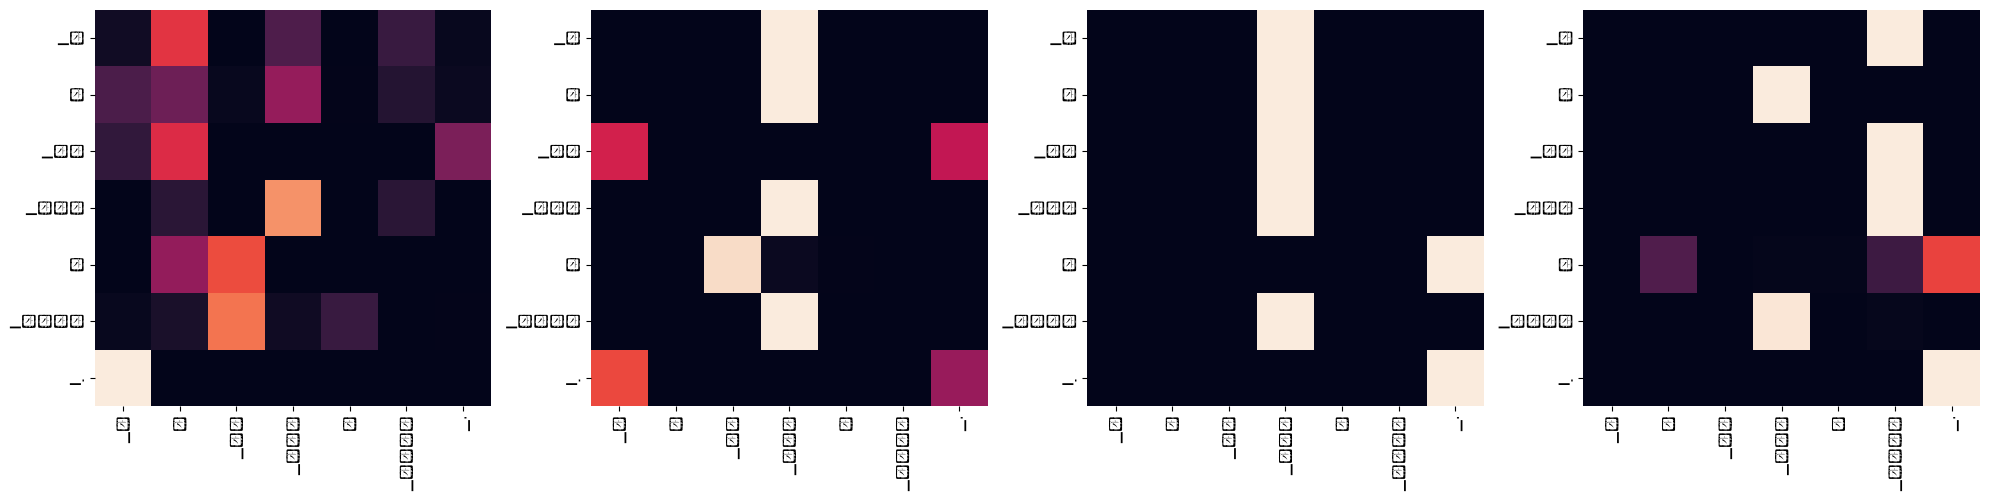

c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Us

Encoder Layer 2


c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-package

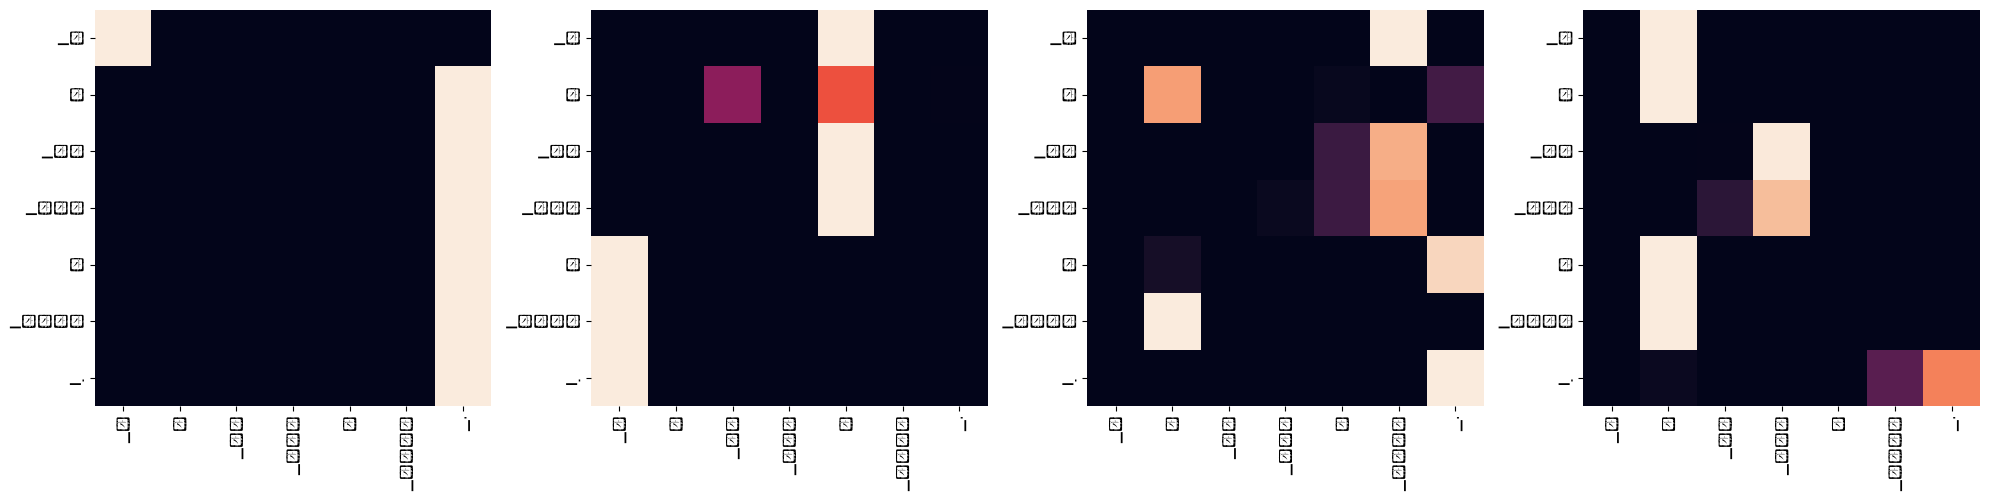

Decoder Self Layer 1


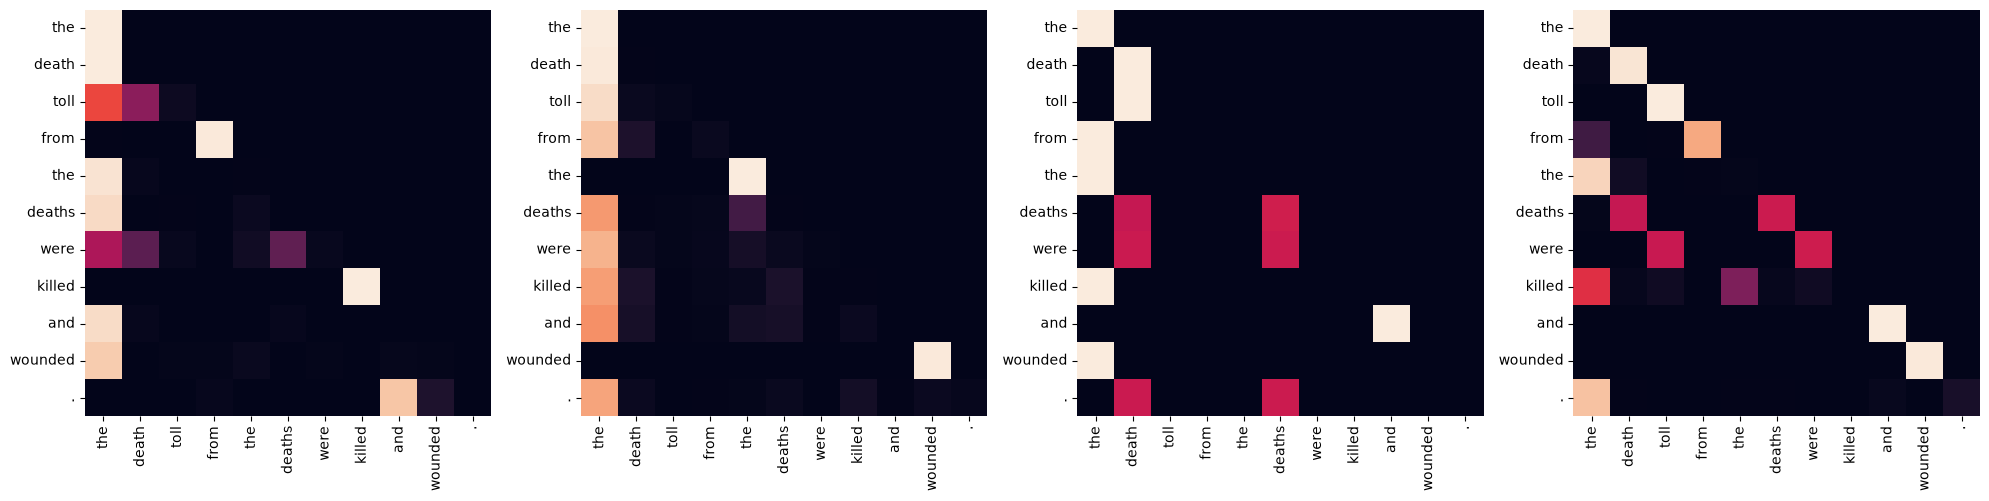

Decoder Src Layer 1


c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Us

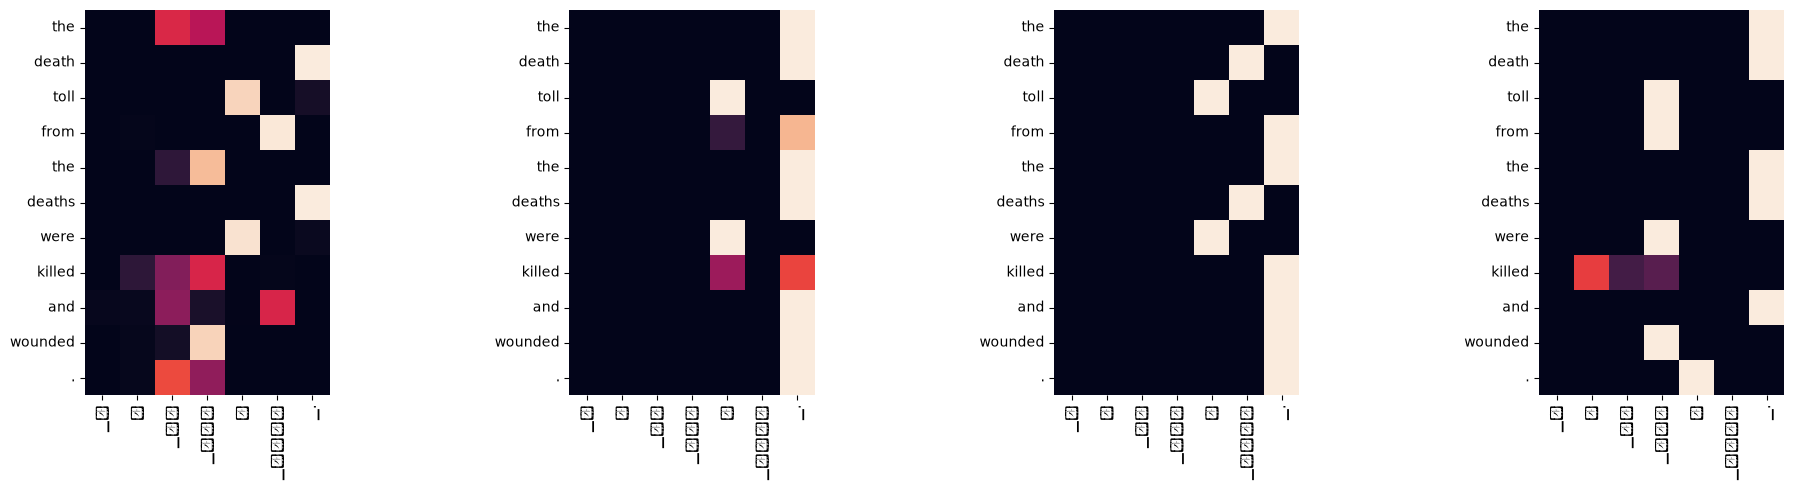

Decoder Self Layer 2


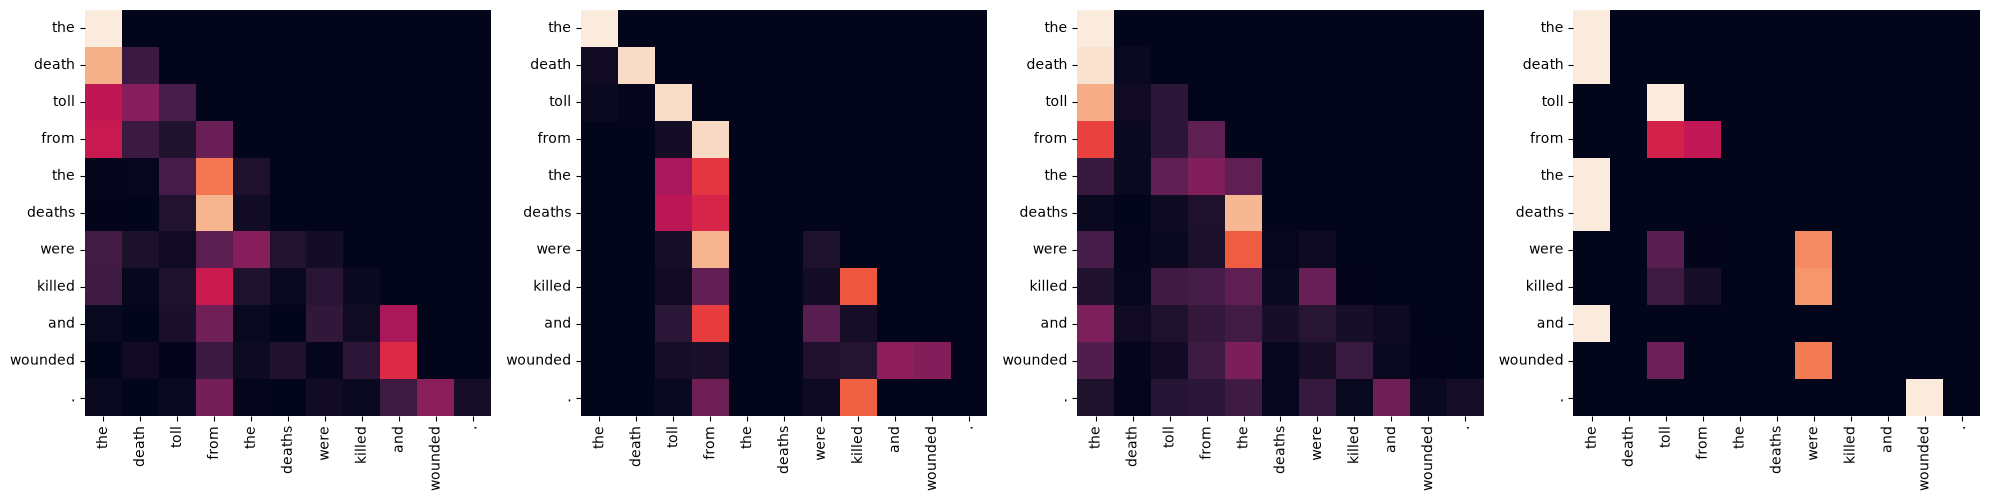

Decoder Src Layer 2


c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\chaej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Us

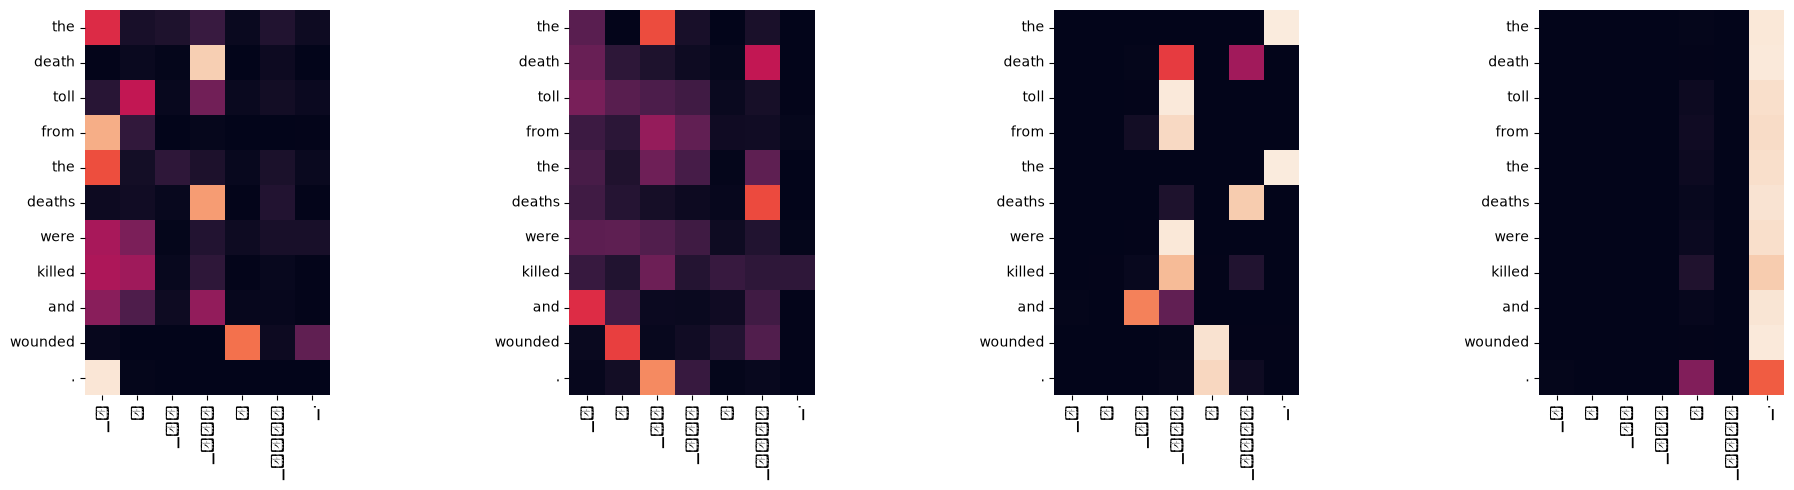

'the death toll from the deaths were killed and wounded .'

In [23]:
# 최종 번역 테스트
for ex in EXAMPLES:
    translate(ex, transformer, ko_tokenizer, en_tokenizer)
    print()

# attention 시각화 (마지막 예문)
translate(EXAMPLES[-1], transformer, ko_tokenizer, en_tokenizer, plot_attention=True)


## 12. 프로젝트 회고

### 학습 지표 요약

| 항목 | 값 |
|------|---|
| 모델 | 2-Layer Pre-LN Transformer |
| 파라미터 수 | 35,214,880 |
| 학습 데이터 | 68,501쌍 (val 3,606쌍, 5%) |
| 최종 avg loss | 4.45 (ep1: 125.6) |
| val BLEU | ep10: 0.0163 → ep20: 0.0246 → ep30: 0.0278 |

---

### 번역 결과 (Epoch 30)

| 입력 | 출력 | 평가 |
|------|------|------|
| 오바마는 대통령이다. | obama is a new president . | ✅ 대체로 성공 |
| 일곱 명의 사망자가 발생했다. | the death toll from the deaths were killed and wounded . | ⚠️ 부분 |
| 커피는 필요 없다. | it s a lot of your child . | ❌ 실패 |
| 시민들은 도시 속에 산다. | the storm is a smaller than a small town . | ❌ 실패 |

**오바마 예문 발전 궤적:**
- ep 1–4: `the the the .`
- ep 10: `obama s president bush s president barack obama such as...`
- ep 17: `obama s a former president .`
- ep 25~30: `obama is a new president .` ✓ 수렴

---

### 회고

**Keep — 유지할 것**
- Noam LR 배치 단위 업데이트 — warmup 곡선 정상 동작
- Pre-LN + weight tying 구조 — 안정적 수렴
- SentencePiece BPE 양방향 분리 학습 (vocab 20,000)
- 검증셋 5% 분리 + epoch별 BLEU 추적 (`VAL_BLEU_EVERY=10`)
- no-repeat trigram 디코딩 — 반복 루프 방지
- epoch별 번역 로그 저장 — 발전 궤적 사후 확인 가능

**Problem — 문제점**
- 최종 BLEU 0.028 — 일상 어휘 번역 대부분 실패
- loss 하강과 BLEU 정체 괴리 — loss만으로 번역 품질 판단 불가
- 2-layer 용량 및 학습 규모 한계 — 복잡한 문장 의미 포착 부족
- cross-attention mask 버그 학습 도중 발견·수정 — encoder-decoder attention에 불필요한 causality mask가 섞일 수 있음을 확인
- LR scheduler off-by-one 버그 (`max(1, self.last_epoch)` → `max(1, self.last_epoch + 1)`)
- 코퍼스 도메인 편향 — 뉴스 특화, 일상 문장 취약

**Try — 다음 시도**
- `n_layers=4`, `EPOCHS=50`, `warmup_steps=6000` 으로 스케일 업
- Beam search (k=4) + no-repeat trigram + length penalty 조합 실험
- Loss curve 시각화 셀 추가
- 학습 전 mask 단위 테스트 작성
- 체크포인트 저장 — 최적 BLEU 모델 보존

- 생각보다 규모때문인지 결과가 예상한만큼 좋게나오진않았다. 시간이 된다면 layer와 epoch를 늘려 추가학습을 해보면 더좋은 결과가 나올 것같다.
